<a href="https://colab.research.google.com/github/ChristianAgyapong/Medgemma/blob/main/TASK_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import the tools we need**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns

**Load the dataset ( no CSV needed)**

In [ ]:
iris = load_iris(as_frame=True)
df = iris.frame

print("Shape:", df.shape)
print("\nFeatures:", iris.feature_names)
print("Classes:", iris.target_names)

# Quick look
print("\nFirst 5 rows:")
print(df.head())

Shape: (150, 5)

Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Classes: ['setosa' 'versicolor' 'virginica']

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  


**Prepare X (features) and y (target)**

In [ ]:
X = df.drop('target', axis=1)
y = df['target']  # 0 = setosa, 1 = versicolor, 2 = virginica

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size :", X_test.shape[0])

Train size: 105
Test size : 45


**Split into train + test**

In [ ]:
# Default tree (can overfit on small data like Iris)
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

# Quick accuracy check
y_pred = tree.predict(X_test)
print("Accuracy (unpruned):", round(accuracy_score(y_test, y_pred), 3))

Accuracy (unpruned): 0.933


**Change words (categories) to numbers**

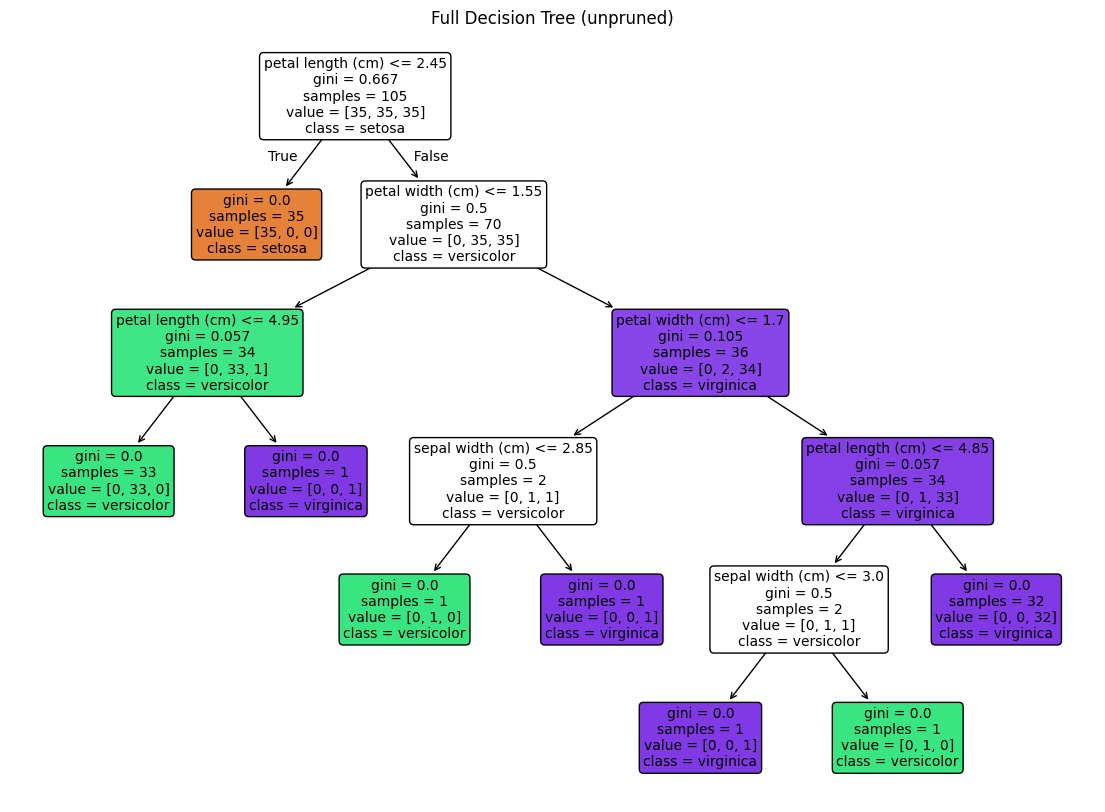

In [ ]:
plt.figure(figsize=(14, 10))
plot_tree(
    tree,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Full Decision Tree (unpruned)")
plt.show()

**Scale (make numbers similar size) – Age and Fare only**

In [ ]:
tree_pruned = DecisionTreeClassifier(
    max_depth=3,           # try 2, 3, or 4 — usually best for Iris
    random_state=42
)
tree_pruned.fit(X_train, y_train)

y_pred_pruned = tree_pruned.predict(X_test)
print("Accuracy (pruned, max_depth=3):", round(accuracy_score(y_test, y_pred_pruned), 3))

Accuracy (pruned, max_depth=3): 0.978


**Separate features (X) and target (y)**

In [ ]:
tree_pruned2 = DecisionTreeClassifier(
    min_samples_leaf=5,    # each final group must have at least 5 samples
    random_state=42
)
tree_pruned2.fit(X_train, y_train)
print("Accuracy (min_samples_leaf=5):", round(accuracy_score(y_test, tree_pruned2.predict(X_test)), 3))

Accuracy (min_samples_leaf=5): 0.889


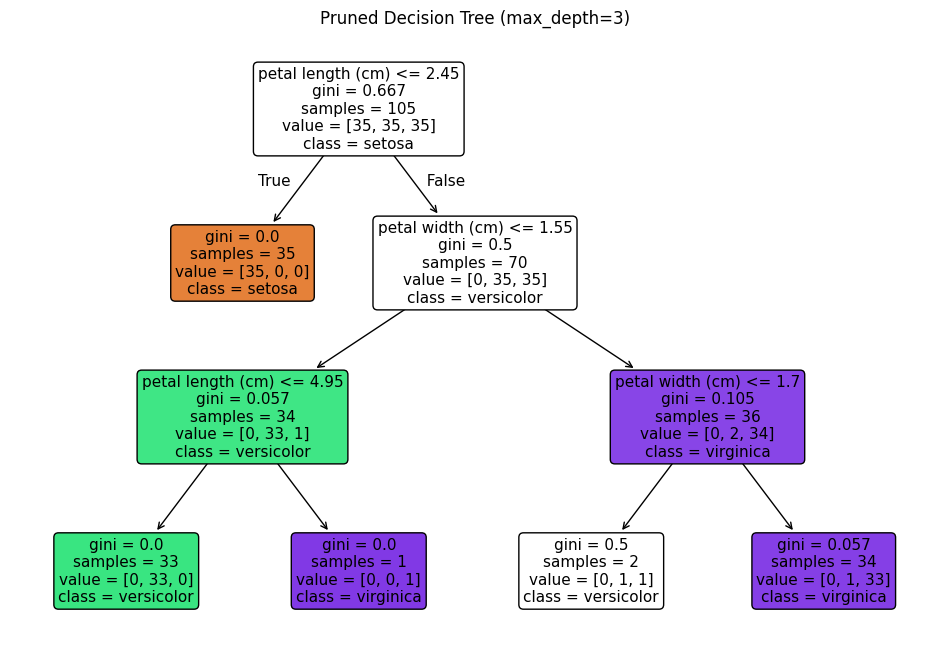

In [ ]:
plt.figure(figsize=(12, 8))
plot_tree(
    tree_pruned,                     # or tree_pruned2
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title("Pruned Decision Tree (max_depth=3)")
plt.show()

Accuracy: 0.978

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       1.00      0.93      0.97        15
   virginica       0.94      1.00      0.97        15

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



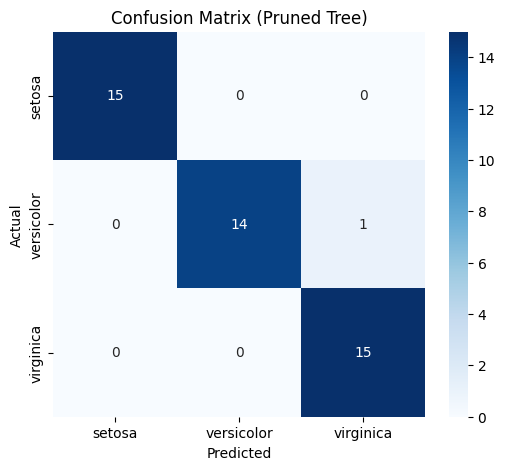

In [ ]:
# Use the pruned model for final evaluation
y_pred = tree_pruned.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Pruned Tree)')
plt.show()

In [ ]:
# Coefficients DataFrame
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0].round(4)
}).sort_values('Coefficient', ascending=False)

print("Top positive coefficients (increase churn probability):")
print(coef_df.head(10))

print("\nTop negative coefficients (decrease churn probability):")
print(coef_df.tail(10))

# Odds ratios = exp(coefficient) → how much odds change per 1 unit increase
coef_df['Odds Ratio'] = np.exp(coef_df['Coefficient']).round(3)
print("\nWith Odds Ratios:")
print(coef_df[['Feature', 'Coefficient', 'Odds Ratio']].head(10))

Top positive coefficients (increase churn probability):
                           Feature  Coefficient
10     InternetService_Fiber optic       1.1807
3                     TotalCharges       0.5278
28  PaymentMethod_Electronic check       0.3928
21                 StreamingTV_Yes       0.3748
26            PaperlessBilling_Yes       0.3742
23             StreamingMovies_Yes       0.3732
9                MultipleLines_Yes       0.3616
0                    SeniorCitizen       0.1479
29      PaymentMethod_Mailed check       0.0819
17            DeviceProtection_Yes       0.0331

Top negative coefficients (decrease churn probability):
                               Feature  Coefficient
12  OnlineSecurity_No internet service      -0.1725
6                       Dependents_Yes      -0.2264
8       MultipleLines_No phone service      -0.2693
19                     TechSupport_Yes      -0.2993
13                  OnlineSecurity_Yes      -0.3491
2                       MonthlyCharges      -0.